Meand Decrease Accuracy:

Contributions:
1. Lopez de Prado - Advances in ML for finance

In [11]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import log_loss
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score


import os
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')


In [12]:
# Load data
df_features = pd.read_csv("final_features.csv", parse_dates=['Date'])
df_features = df_features.set_index('Date')

df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

data = pd.concat([df_features,df_factor], axis=1, join='inner')
data = data.dropna()

X = data.iloc[:, :-2]
y = data['Momentum_vs_Value_trend'].values

X = pd.DataFrame(
    np.nan_to_num(X.values, nan=0.0, posinf=1e10, neginf=-1e10), 
    columns=X.columns, 
    index=X.index
)


In [ ]:
print(X)
print(y)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.
 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.
 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.

In [23]:

def feature_importance_mda_walkforward(clf, X, y, test_size=0.2, scoring='neg_log_loss', min_train_size=0.2):
    
    # Mean Decrease Accuracy (MDA) feature importance using walk-forward validation.

    n_samples = len(X)
    test_len = int(n_samples * test_size)
    start_train = int(n_samples * min_train_size)

    importance = pd.DataFrame(index=X.columns, dtype='float64')

    split_num = 0
    for start in range(start_train, n_samples - test_len + 1): 
        train_idx = np.arange(0, start)
        test_idx = np.arange(start, start + test_len)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit base model
        clf_ = clone(clf)
        clf_.fit(X_train, y_train)

        # Baseline performance
        if scoring == 'neg_log_loss':
            prob = clf_.predict_proba(X_test)
            baseline_score = -log_loss(y_test, prob)
        elif scoring == 'accuracy':
            pred = clf_.predict(X_test)
            baseline_score = accuracy_score(y_test, pred)
        else:
            raise ValueError("Unsupported scoring metric")

        # Permutation importance per feature
        for col in X.columns:
            X_test_permuted = X_test.copy()
            X_test_permuted[col] = np.random.permutation(X_test_permuted[col])

            if scoring == 'neg_log_loss':
                prob = clf_.predict_proba(X_test_permuted)
                permuted_score = -log_loss(y_test, prob)
            elif scoring == 'accuracy':
                pred = clf_.predict(X_test_permuted)
                permuted_score = accuracy_score(y_test, pred)

            drop = baseline_score - permuted_score
            importance.loc[col, split_num] = drop

        split_num += 1

    # Mean & std across walk-forward splits
    imp_mean = importance.mean(axis=1)
    imp_std = importance.std(axis=1)
    result = pd.DataFrame({'mean_importance': imp_mean, 'std_importance': imp_std})
    return result.sort_values('mean_importance', ascending=False)

#clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf = XGBClassifier(n_estimators=100, random_state=42)
importance_df = feature_importance_mda_walkforward(clf, X, y, test_size=0.2, min_train_size=0.5)



C:\Users\p528552\AppData\Local\Temp\ipykernel_28820\2435769924.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  importance.loc[col, split_num] = drop
C:\Users\p528552\AppData\Local\Temp\ipykernel_28820\2435769924.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  importance.loc[col, split_num] = drop
C:\Users\p528552\AppData\Local\Temp\ipykernel_28820\2435769924.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

In [ ]:
def plot_feature_importance(importance_df, top_n=None):

    if top_n is not None:
        importance_df = importance_df.head(top_n)
    
    # Sort for horizontal bar plot
    importance_df = importance_df.sort_values('mean_importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df.index,
        importance_df['mean_importance'],
        xerr=importance_df['std_importance'],
        align='center',
        color='skyblue',
        ecolor='gray',
        capsize=5
    )
    
    plt.xlabel("Mean Importance Score")
    plt.ylabel("Features")
    plt.title("Feature Importance with Standard Deviation (MDA Method)")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

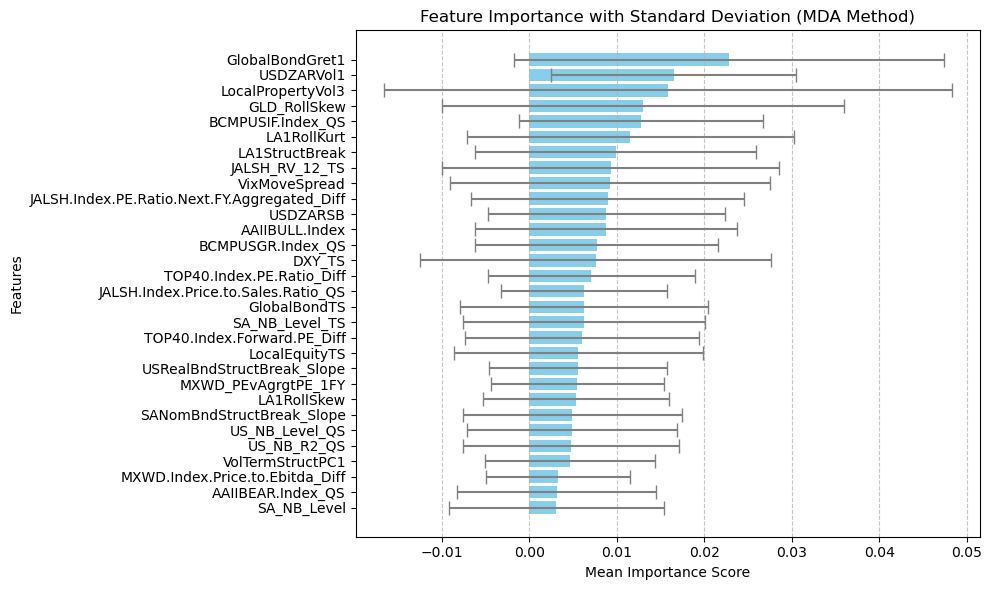

In [ ]:
plot_feature_importance(importance_df, top_n=30)

In [ ]:
    # Display results
print("Top 10 Most Important Features:")
print(importance_df.head(20))

Top 10 Most Important Features:
                                              mean_importance  std_importance
GlobalBondGret1                                      0.022822        0.024601
USDZARVol1                                           0.016502        0.013975
LocalPropertyVol3                                    0.015848        0.032430
GLD_RollSkew                                         0.013010        0.022948
BCMPUSIF.Index_QS                                    0.012780        0.013985
LA1RollKurt                                          0.011565        0.018682
LA1StructBreak                                       0.009894        0.016048
JALSH_RV_12_TS                                       0.009325        0.019260
VixMoveSpread                                        0.009215        0.018268
JALSH.Index.PE.Ratio.Next.FY.Aggregated_Diff         0.008985        0.015620
USDZARSB                                             0.008818        0.013536
AAIIBULL.Index                  

In [25]:
# Select top features by mean importance
top_features = importance_df.head(60).index

# Cut down original dataset
X_top50 = X[top_features]

# (Optional) keep labels together
#data_top50 = pd.concat([X_top50, pd.Series(y, index=X.index, name='trend_bin')], axis=1)

# Save to CSV
X_top50.to_csv("top50_features.csv", index=True)

print("Saved reduced dataset with top 50 features to top50_features_dataset.csv")


Saved reduced dataset with top 50 features to top50_features_dataset.csv


In [26]:
print(X_top50)

            GlobalBondGret1  USDZARVol1  LocalPropertyVol3  BCMPUSIF.Index_QS  \
Date                                                                            
2007-12-24        -0.039605    0.042196           0.056023              0.130   
2007-12-31        -0.024025    0.060992           0.058412              0.215   
2008-01-07         0.003453    0.050505           0.059561              0.185   
2008-01-14         0.022949    0.066314           0.061937              0.430   
2008-01-21         0.037942    0.058958           0.057254              0.785   
...                     ...         ...                ...                ...   
2023-12-04        -0.012225    0.039467           0.079283              0.260   
2023-12-11        -0.007109    0.046277           0.079253              0.250   
2023-12-18        -0.035456    0.047068           0.088718              0.170   
2023-12-25        -0.034978    0.053746           0.085545              0.165   
2024-01-01        -0.031034 